# Distance & Disease

## Infrastructure Isolation and Diabetes Prevalence Across U.S. Counties

### Data Science Capstone | Portfolio Analytics Pipeline

---

## 1. Project Overview & Executive Summary

This project investigates the relationship between transportation-related food access barriers and diabetes prevalence across U.S. counties.

Using county-level data from the USDA Food Environment Atlas and CDC PLACES datasets, the analysis examines whether communities with larger populations experiencing both low food access and limited vehicle access tend to exhibit higher rates of diabetes.

### Feature Selection & Scope Refinement

**Initial Exploratory Scope**

The project initially evaluated several food environment and public health indicators, including:

* Low-income, low-food-access population percentage
* Low-food-access population without vehicle access
* Healthy food retailers per 1,000 residents
* Convenience stores per 1,000 residents
* Fast-food restaurants per 1,000 residents
* Obesity prevalence
* Diabetes prevalence

**Exploratory Findings**

Correlation analysis identified two of the strongest positive associations with county-level diabetes prevalence:

1. **Low Food Access and Limited Vehicle Access** ($r \approx 0.60$)
2. **Convenience Store Density** ($r \approx 0.47$)

**Final Variable Selection**

The percentage of residents experiencing both low food access and limited vehicle access demonstrated the strongest relationship with diabetes prevalence and was selected as the primary explanatory variable for subsequent modeling.

Focusing on a single explanatory variable allowed the analysis to maintain a clear and interpretable modeling framework while examining the relationship between transportation-related food access barriers and diabetes prevalence.

### Core Methodology

* **Data Integration:** USDA Food Environment Atlas and CDC PLACES datasets were imported into SQLite and joined using geographic identifiers.
* **Data Preparation:** County-level records were cleaned, validated, and standardized for analysis.
* **Statistical Modeling:** Correlation analysis, Ordinary Least Squares (OLS) regression, and regional stratification.
* **Visualization:** Python-based exploratory analysis and Tableau dashboard development.

## 2. Environment Initialization

The analytical environment is initialized using Python libraries for data manipulation, visualization, and statistical modeling.


In [1]:
# Core data manipulation frameworks
import pandas as pd
import numpy as np
import sqlite3

# Statistical modeling and empirical validation
import statsmodels.api as sm
import scipy.stats as stats

# Exploded visualization and exploratory plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment successfully initialized with full dependency stack.")

Environment successfully initialized with full dependency stack.


## 3. Data Ingestion & Relational Database Staging

The raw CSV datasets from the USDA Food Environment Atlas and CDC PLACES were imported into a local SQLite database (`health_data.db`) to support structured querying and dataset integration.

This approach allowed for efficient data joining and transformation using SQL, particularly for merging county-level records across multiple sources using geographic identifiers (FIPS codes). After joining, the resulting dataset was exported into a Pandas DataFrame for exploratory analysis and modeling in Python.


In [2]:
# 1. Instantiate the local SQLite relational database connection
conn = sqlite3.connect('health_data.db')

# 2. Extract raw source flat-files from disk
print("Extracting source datasets...")
usda_df = pd.read_csv('data/StateAndCountyData.csv') 
cdc_df = pd.read_csv('data/PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260522.csv', low_memory=False)

# 3. Stage data assets into the relational database environment
print("Migrating raw assets into SQLite database staging tables...")
usda_df.to_sql('raw_usda_data', conn, if_exists='replace', index=False)
cdc_df.to_sql('raw_cdc_data', conn, if_exists='replace', index=False)

print("Database sandbox successfully built! Analytics warehouse ready for querying.")

Extracting source datasets...
Migrating raw assets into SQLite database staging tables...
Database sandbox successfully built! Analytics warehouse ready for querying.


## 4. Analytical Extraction & Geospatial Key Standardization

After staging the data in SQLite, an external SQL script (`01_data_extraction.sql`) was used to join USDA and CDC datasets on county-level geographic identifiers (FIPS codes).

Following extraction into a Pandas DataFrame, a key data cleaning issue was addressed involving inconsistent formatting of FIPS codes. Because these identifiers are sometimes interpreted as numeric values, leading zeros were dropped (e.g., `06037` becomes `6037.0`), which would prevent accurate geographic joins.

To standardize the geographic keys for analysis and mapping, the following cleaning steps were applied:

1. Removal of trailing decimal formatting introduced during numeric conversion
2. Handling of missing or invalid string values (e.g., `'nan'`)
3. Reformatting all valid FIPS codes to a consistent 5-digit string format using zero-padding

This ensured consistent geographic identifiers across both datasets for accurate merging and spatial analysis.


In [3]:
# 1. Extract unified dataset via compiled external relational join script
with open('01_data_extraction.sql', 'r') as f:
    sql_query = f.read()

results_df = pd.read_sql_query(sql_query, conn)

# 2. Vectorized string manipulation: Strip floating-point decimal artifacts
results_df['FIPS'] = results_df['FIPS'].astype(str).str.split('.').str[0]

# 3. Handle data mutation anomalies by replacing string-literal 'nan' with explicit Python None
results_df['FIPS'] = results_df['FIPS'].replace('nan', None)

# 4. Standardize geospatial keys: Execute conditional right-aligned zero-fill padding to a 5-digit width
results_df['FIPS'] = results_df['FIPS'].apply(lambda x: x.zfill(5) if x is not None else None)

# 5. Pipeline sanity check: Inspect the head of the transformed data asset
results_df.head(20)

,FIPS,State,County,pct_low_income_low_access,pct_no_car_low_access,healthy_retailers_per_1k,convenience_stores_per_1k,fast_food_per_1k,diabetes_rate,obesity_rate
0,None,AK,Aleutian Islands Area,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
1,02013,AK,Aleutians East,14.590333,22.749483,1.176125,NaN,NaN,12.8,30.7
2,02016,AK,Aleutians West,7.808430,11.037880,0.000000,NaN,NaN,10.8,31.9
3,02020,AK,Anchorage,4.570024,0.920271,0.142810,0.167192,0.741915,8.9,35.0
4,None,AK,Anchorage Area,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
5,02050,AK,Bethel,39.852650,49.453529,1.139014,0.325433,0.325433,13.8,39.1
6,02060,AK,Bristol Bay,11.679363,9.894739,0.000000,NaN,NaN,11.3,34.9
7,02063,AK,Chugach,NaN,NaN,0.000000,NaN,NaN,9.6,31.1
8,02066,AK,Copper River,NaN,NaN,0.000000,NaN,NaN,11.4,33.6
9,02068,AK,Denali,33.091450,3.107553,0.000000,NaN,1.441615,8.6,31.3


## 5. Exploratory Data Profiling & Baseline Diagnostics

Before modeling, an initial exploratory data analysis (EDA) phase was conducted to understand the structure and distribution of the dataset.

This step focused on three core checks:

1. **Dataset Structure**
   Reviewed the number of rows and columns to understand overall dataset size and coverage.

2. **Data Types and Format Consistency**
   Verified that variables were correctly interpreted as numeric or categorical values to ensure reliable analysis.

3. **Summary Statistics**
   Generated descriptive statistics (mean, standard deviation, and percentiles) to understand baseline distributions and identify potential anomalies or scaling issues in key variables.

These steps provided a foundational understanding of the dataset prior to correlation analysis and modeling.


In [4]:
# 1. Inspect the macro structural dimensions of the DataFrame matrix
print("========================================================================")
print(f"DATASET MATRIX SHAPE: {results_df.shape[0]} rows | {results_df.shape[1]} columns")
print("========================================================================\n")

# 2. Audit structural data types, non-null counts, and system memory allocations
print("--- Core Schema & Data Type Diagnostics ---")
results_df.info()

print("\n--- Transposed Statistical Distribution Matrix ---")
# Transposing the summary output ensures optimal horizontal scannability for multi-feature schemas
statistical_profile = results_df.describe().T
print(statistical_profile)

DATASET MATRIX SHAPE: 3161 rows | 10 columns

--- Core Schema & Data Type Diagnostics ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3161 entries, 0 to 3160
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   FIPS                       3156 non-null   object 
 1   State                      3161 non-null   object 
 2   County                     3161 non-null   object 
 3   pct_low_income_low_access  3141 non-null   float64
 4   pct_no_car_low_access      3141 non-null   float64
 5   healthy_retailers_per_1k   3161 non-null   float64
 6   convenience_stores_per_1k  2859 non-null   float64
 7   fast_food_per_1k           2672 non-null   float64
 8   diabetes_rate              2956 non-null   float64
 9   obesity_rate               2956 non-null   float64
dtypes: float64(7), object(3)
memory usage: 247.1+ KB

--- Transposed Statistical Distribution Matrix ---
                         

## 6. Missing Data Analysis & Geographic Coverage

Before performing data filtering, the dataset was evaluated for missing values and geographic completeness.

This step served two purposes:

### 1. Missing Data Assessment

Missing values were quantified across all variables by calculating the percentage of null entries in each column. This helped identify variables with incomplete coverage and informed decisions about which features could be reliably included in the analysis.

### 2. Geographic Coverage Check

The dataset was reviewed to confirm which states and regions were represented. This included verifying the presence of all U.S. states and identifying any geographic areas with incomplete or missing reporting.

This step ensured that the final dataset used for analysis was geographically consistent and suitable for county-level comparisons.


In [5]:
# 1. Quantify the relative density of missing values across the feature space
print("========================================================================")
print("RELATIVE DENSITY OF MISSING VALUES (% BY FEATURE)")
print("========================================================================")
missing_percentage = (results_df.isnull().sum() / len(results_df)) * 100
print(missing_percentage.round(2).astype(str) + '%')

# 2. Audit the geopolitical scope of the current data extraction
print("\n========================================================================")
print("GEOPOLITICAL BOUNDARY AUDIT")
print("========================================================================")
unique_state_count = results_df['State'].nunique()
print(f"Total Unique Geopolitical Jurisdictions Represented: {unique_state_count}\n")

print("Alphabetical System Inventory:")
observed_states = sorted(results_df['State'].dropna().unique())
print(observed_states)

RELATIVE DENSITY OF MISSING VALUES (% BY FEATURE)
FIPS                          0.16%
State                          0.0%
County                         0.0%
pct_low_income_low_access     0.63%
pct_no_car_low_access         0.63%
healthy_retailers_per_1k       0.0%
convenience_stores_per_1k     9.55%
fast_food_per_1k             15.47%
diabetes_rate                 6.49%
obesity_rate                  6.49%
dtype: object

GEOPOLITICAL BOUNDARY AUDIT
Total Unique Geopolitical Jurisdictions Represented: 51

Alphabetical System Inventory:
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']


## 7. Missing Data Patterns & Dataset Completeness

Before removing incomplete records, the distribution of missing values was examined to understand patterns of data availability across the dataset.

In public health datasets, missing values can occur for several reasons, including reporting thresholds, privacy-related suppression in small populations, or differences in data collection methods across agencies.

During this analysis, several states showed a higher concentration of missing values in key epidemiological indicators, resulting in gaps in county-level coverage within the merged dataset.

Further investigation suggests that these gaps are likely due to differences in geographic coverage and reporting alignment between the USDA Food Environment Atlas and CDC PLACES datasets.

These missing regions were documented and accounted for prior to finalizing the analytical dataset used in modeling and visualization.


In [6]:
# 1. Isolate records where socioeconomic infrastructure exists but epidemiological outcomes are suppressed
missing_health_data = results_df[results_df['diabetes_rate'].isna() & results_df['pct_no_car_low_access'].notna()]

# 2. Quantify the absolute frequency of data suppression stratified by state jurisdiction
suppression_by_state = missing_health_data['State'].value_counts()

print("========================================================================")
print("SYSTEMATIC DATA SUPPRESSION AUDIT BY STATE")
print("========================================================================")
print(suppression_by_state)

print("\n========================================================================")
print("SAMPLE OF LOGISTICAL RECORDS IMPACTED BY EPIDEMIOLOGICAL SUPPRESSION")
print("========================================================================")
print(missing_health_data[['County', 'State', 'pct_no_car_low_access']].head(15))

SYSTEMATIC DATA SUPPRESSION AUDIT BY STATE
State
KY    120
PA     67
CT      8
TX      1
Name: count, dtype: int64

SAMPLE OF LOGISTICAL RECORDS IMPACTED BY EPIDEMIOLOGICAL SUPPRESSION
          County State  pct_no_car_low_access
317    Fairfield    CT               1.034398
319     Hartford    CT               1.293207
320   Litchfield    CT               2.251744
322    Middlesex    CT               1.641936
324    New Haven    CT               1.571892
325   New London    CT               1.867415
330      Tolland    CT               2.407017
332      Windham    CT               2.471505
1010       Adair    KY               3.200161
1011       Allen    KY               5.875364
1012    Anderson    KY               2.204920
1013     Ballard    KY               4.804646
1014      Barren    KY               2.752531
1015        Bath    KY               8.489875
1016        Bell    KY               9.130505


## 8. Final Dataset Filtering (Listwise Deletion)

After documenting and analyzing missing data patterns, the dataset was filtered to include only complete records for the variables used in the final analysis.

Rows with missing values in key features were removed to ensure consistency across all variables used in modeling and visualization.

While this approach reduces the total number of observations, it ensures that all remaining counties included in the analysis have complete data across the selected features, allowing for a consistent and comparable dataset for statistical modeling.


In [7]:
# 1. Create a protective backup copy of the raw staging dataframe
df_clean = results_df.copy()

# 2. Programmatically drop Alaska utilizing its definitive FIPS prefix ('02')
df_clean = df_clean[~df_clean['FIPS'].str.startswith('02', na=True)]

# 3. Apply listwise deletion strictly across our core analytical feature vector
df_clean = df_clean.dropna(subset=['pct_low_income_low_access', 'pct_no_car_low_access', 
                                   'convenience_stores_per_1k', 'fast_food_per_1k', 'diabetes_rate'])

print("========================================================================")
print("DATA CLEANING PIPELINE COMPLETE")
print("========================================================================")
print(f"Original Staging Dataset Volume : {len(results_df)} counties")
print(f"Cleaned Regression-Ready Volume: {len(df_clean)} counties")
print(f"Total Records Excluded          : {len(results_df) - len(df_clean)} counties")

DATA CLEANING PIPELINE COMPLETE
Original Staging Dataset Volume : 3161 counties
Cleaned Regression-Ready Volume: 2427 counties
Total Records Excluded          : 734 counties


## 9. Regional Cohort Stratification & Outlier Exploration

To explore regional variation in infrastructure isolation and diabetes prevalence, the dataset was segmented into geographic cohorts, with particular focus on the Southeast/Appalachia region and the Southwest region.

These regions were selected based on observed differences in both infrastructure isolation and diabetes prevalence during exploratory analysis.

To better understand distributional patterns in the data, a two-part exploratory review was conducted:

### 1. Upper-Tail Distribution Review

The counties with the highest levels of infrastructure isolation were isolated to examine extreme values in the dataset.

### 2. Outlier Identification and Contextual Review

Several counties in the upper tail exhibited unusually high rates of vehicle-related isolation. Notably, counties such as Holmes County, OH and LaGrange County, IN appear as outliers in this distribution.

These counties are associated with Amish communities, where lower vehicle ownership may reflect cultural and lifestyle factors rather than typical indicators of transportation disadvantage.

These observations were documented and considered in the interpretation of the overall relationship between infrastructure isolation and diabetes prevalence.

These observations are further explored in the following visualizations, which compare the full distribution against a filtered dataset with identified outliers removed.


In [8]:
# 1. Isolate and sort the upper-tail distribution of vehicle-less infrastructure isolation
top_isolated = df_clean[['County', 'State', 'pct_no_car_low_access', 'diabetes_rate']].sort_values(
    by='pct_no_car_low_access', 
    ascending=False
)

# 2. Inspect the top 30 counties to detect potential socio-cultural and administrative outliers
print("========================================================================")
print("UPPER-TAIL DISTRIBUTION AUDIT: TOP 30 MOST ISOLATED COUNTIES")
print("========================================================================")
print(top_isolated.head(30))

UPPER-TAIL DISTRIBUTION AUDIT: TOP 30 MOST ISOLATED COUNTIES
             County State  pct_no_car_low_access  diabetes_rate
2097         Holmes    OH              26.037796           12.7
856        LaGrange    IN              24.029560           12.4
102          Wilcox    AL              14.851606           23.8
1592        Quitman    MS              13.465470           22.8
3109       McDowell    WV              12.776709           21.6
2918     Petersburg    VA              12.585870           19.2
157        Phillips    AR              12.009425           21.7
2026     Montgomery    NY              11.367007           11.5
179          Apache    AZ              11.216977           17.5
826         Daviess    IN              10.990121           13.8
2429  Oglala Lakota    SD              10.842655           21.1
3112          Mingo    WV              10.717805           20.4
523        Randolph    GA              10.460299           24.9
171     St. Francis    AR              10.3

### Regional Cohort Comparison

Following identification of regional patterns and outliers, summary statistics were calculated to compare infrastructure isolation and diabetes prevalence across selected geographic cohorts.

National median values were used as a baseline for comparison.

Regional values for the Southeast/Appalachia and Southwest cohorts were then compared against these national benchmarks to assess differences in distributional patterns across geography.

This comparison highlights variation in both infrastructure isolation and diabetes prevalence between regions and the national average, which is further explored in the visualization section.


In [9]:
# 1. Establish the objective national baseline control medians
national_median_isolation = df_clean['pct_no_car_low_access'].median()
national_median_diabetes = df_clean['diabetes_rate'].median()

# 2. Segment and aggregate the Southeast & Appalachian Core Cohort
southeast_states = ['MS', 'AL', 'GA', 'LA', 'WV', 'AR', 'VA', 'SC', 'TN', 'NC']
regional_profile = df_clean[df_clean['State'].isin(southeast_states)][['pct_no_car_low_access', 'diabetes_rate']].median()
se_county_count = len(df_clean[df_clean['State'].isin(southeast_states)])

# 3. Segment and aggregate the Southwest Cohort
southwest_states = ['AZ', 'NM']
sw_profile = df_clean[df_clean['State'].isin(southwest_states)][['pct_no_car_low_access', 'diabetes_rate']].median()
sw_county_count = len(df_clean[df_clean['State'].isin(southwest_states)])

# 4. Generate professional, publication-ready reporting summaries
print("========================================================================")
print("GEOGRAPHICAL INFRASTRUCTURE & EPIDEMIOLOGICAL BASELINES")
print("========================================================================")
print(f"NATIONAL BASESLINES:")
print(f"  • Median Infrastructure Isolation : {national_median_isolation:.2f}%")
print(f"  • Median Diabetes Prevalence       : {national_median_diabetes:.2f}%\n")

print(f"SOUTHEAST & APPALACHIAN COHORT (N = {se_county_count} counties):")
print(f"  • Regional Median Isolation       : {regional_profile['pct_no_car_low_access']:.2f}%")
print(f"  • Regional Median Diabetes         : {regional_profile['diabetes_rate']:.2f}%")
print(f"  • Shift Relative to National Base  : +{(regional_profile['diabetes_rate'] - national_median_diabetes):.2f}% higher prevalence\n")

print(f"SOUTHWEST COHORT (N = {sw_county_count} counties):")
print(f"  • Regional Median Isolation       : {sw_profile['pct_no_car_low_access']:.2f}%")
print(f"  • Regional Median Diabetes         : {sw_profile['diabetes_rate']:.2f}%")
print(f"  • Shift Relative to National Base  : +{(sw_profile['diabetes_rate'] - national_median_diabetes):.2f}% higher prevalence")
print("========================================================================")

GEOGRAPHICAL INFRASTRUCTURE & EPIDEMIOLOGICAL BASELINES
NATIONAL BASESLINES:
  • Median Infrastructure Isolation : 2.52%
  • Median Diabetes Prevalence       : 13.20%

SOUTHEAST & APPALACHIAN COHORT (N = 796 counties):
  • Regional Median Isolation       : 3.49%
  • Regional Median Diabetes         : 15.25%
  • Shift Relative to National Base  : +2.05% higher prevalence

SOUTHWEST COHORT (N = 40 counties):
  • Regional Median Isolation       : 2.78%
  • Regional Median Diabetes         : 14.50%
  • Shift Relative to National Base  : +1.30% higher prevalence


In [10]:
# 1. Establish the objective national baseline control medians
national_median_isolation = df_clean['pct_no_car_low_access'].median()
national_median_diabetes = df_clean['diabetes_rate'].median()

# 2. Segment and aggregate the Southeast & Appalachian Core Cohort
southeast_states = ['MS', 'AL', 'GA', 'LA', 'WV', 'AR', 'VA', 'SC', 'TN', 'NC']
regional_profile = df_clean[df_clean['State'].isin(southeast_states)][['pct_no_car_low_access', 'diabetes_rate']].median()
se_county_count = len(df_clean[df_clean['State'].isin(southeast_states)])

# 3. Segment and aggregate the Southwest Cohort
southwest_states = ['AZ', 'NM']
sw_profile = df_clean[df_clean['State'].isin(southwest_states)][['pct_no_car_low_access', 'diabetes_rate']].median()
sw_county_count = len(df_clean[df_clean['State'].isin(southwest_states)])

# 4. Generate professional, publication-ready reporting summaries
print("========================================================================")
print("GEOGRAPHICAL INFRASTRUCTURE & EPIDEMIOLOGICAL BASELINES")
print("========================================================================")
print(f"NATIONAL BASESLINES:")
print(f"  • Median Infrastructure Isolation : {national_median_isolation:.2f}%")
print(f"  • Median Diabetes Prevalence       : {national_median_diabetes:.2f}%\n")

print(f"SOUTHEAST & APPALACHIAN COHORT (N = {se_county_count} counties):")
print(f"  • Regional Median Isolation       : {regional_profile['pct_no_car_low_access']:.2f}%")
print(f"  • Regional Median Diabetes         : {regional_profile['diabetes_rate']:.2f}%")
print(f"  • Shift Relative to National Base  : +{(regional_profile['diabetes_rate'] - national_median_diabetes):.2f}% higher prevalence\n")

print(f"SOUTHWEST COHORT (N = {sw_county_count} counties):")
print(f"  • Regional Median Isolation       : {sw_profile['pct_no_car_low_access']:.2f}%")
print(f"  • Regional Median Diabetes         : {sw_profile['diabetes_rate']:.2f}%")
print(f"  • Shift Relative to National Base  : +{(sw_profile['diabetes_rate'] - national_median_diabetes):.2f}% higher prevalence")
print("========================================================================")

GEOGRAPHICAL INFRASTRUCTURE & EPIDEMIOLOGICAL BASELINES
NATIONAL BASESLINES:
  • Median Infrastructure Isolation : 2.52%
  • Median Diabetes Prevalence       : 13.20%

SOUTHEAST & APPALACHIAN COHORT (N = 796 counties):
  • Regional Median Isolation       : 3.49%
  • Regional Median Diabetes         : 15.25%
  • Shift Relative to National Base  : +2.05% higher prevalence

SOUTHWEST COHORT (N = 40 counties):
  • Regional Median Isolation       : 2.78%
  • Regional Median Diabetes         : 14.50%
  • Shift Relative to National Base  : +1.30% higher prevalence


## 10. Feature Correlation Analysis & Selection

To explore relationships between variables, a Pearson correlation matrix was computed across all engineered features in the dataset. This included measures of food access, vehicle access, convenience store density, fast-food density, obesity prevalence, and diabetes prevalence.

The resulting correlation matrix was used to identify which variables showed the strongest linear relationships with diabetes prevalence.

This analysis helped guide feature selection for the final modeling stage by highlighting the infrastructure-related variables most strongly associated with the target outcome.


In [11]:
# Select all exploratory features for the macro-level audit
exploratory_features = [
    'pct_no_car_low_access', 'pct_low_income_low_access', 
    'convenience_stores_per_1k', 'fast_food_per_1k', 
    'obesity_rate', 'diabetes_rate'
]
macro_corr_matrix = df_clean[exploratory_features].corr()

print("========================================================================")
print("MACRO-FEATURE CORRELATION AUDIT (PEARSON'S r)")
print("========================================================================")
print(macro_corr_matrix.round(3))

MACRO-FEATURE CORRELATION AUDIT (PEARSON'S r)
                           pct_no_car_low_access  pct_low_income_low_access  \
pct_no_car_low_access                      1.000                      0.255   
pct_low_income_low_access                  0.255                      1.000   
convenience_stores_per_1k                  0.303                      0.133   
fast_food_per_1k                          -0.208                      0.087   
obesity_rate                               0.443                      0.189   
diabetes_rate                              0.595                      0.246   

                           convenience_stores_per_1k  fast_food_per_1k  \
pct_no_car_low_access                          0.303            -0.208   
pct_low_income_low_access                      0.133             0.087   
convenience_stores_per_1k                      1.000             0.155   
fast_food_per_1k                               0.155             1.000   
obesity_rate                  

### Bivariate Analysis & Visualization

To examine the relationship between infrastructure-related food access and diabetes prevalence, the primary variable of interest (`pct_no_car_low_access`) was compared against `diabetes_rate`.

Two visualizations were used to explore this relationship:

1. **Correlation Heatmap (Left Panel)**
   Displays Pearson correlation values across key variables in the dataset to summarize overall linear relationships.

2. **Scatter Plot with OLS Trendline (Right Panel)**
   Shows the relationship between the selected variables at the county level, with an Ordinary Least Squares (OLS) regression line fitted to the data.

This visualization helps illustrate the overall distribution of the data and highlights potential outliers and variation in the relationship across counties.


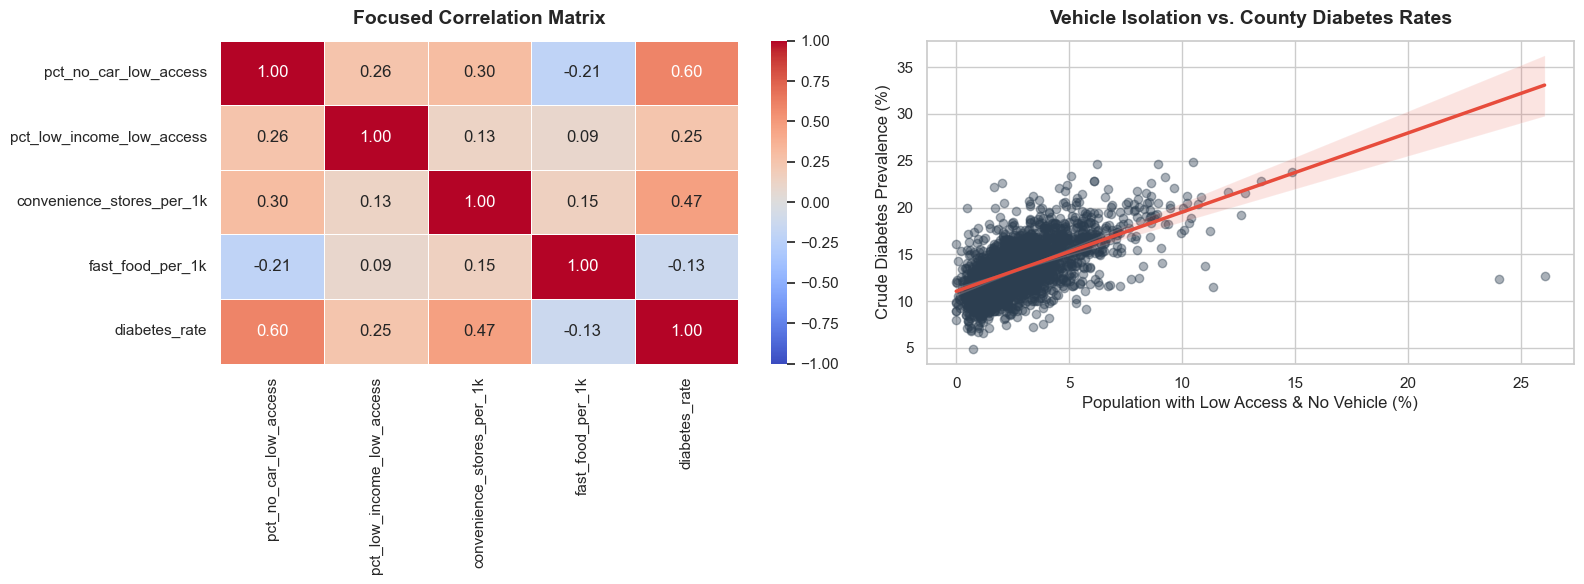

In [12]:
# Focus strictly on our primary regression vector variables
focused_features = ['pct_no_car_low_access', 'pct_low_income_low_access', 'convenience_stores_per_1k', 'fast_food_per_1k', 'diabetes_rate']
focused_corr_matrix = df_clean[focused_features].corr()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Heatmap
sns.heatmap(focused_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Focused Correlation Matrix", fontsize=14, fontweight='bold', pad=12)

# Right plot: Scatter with OLS trendline
sns.regplot(data=df_clean, x='pct_no_car_low_access', y='diabetes_rate',
            scatter_kws={'alpha':0.4, 'color': '#2c3e50'}, line_kws={'color': '#e74c3c', 'linewidth': 2.5}, ax=axes[1])
axes[1].set_title("Vehicle Isolation vs. County Diabetes Rates", fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel("Population with Low Access & No Vehicle (%)")
axes[1].set_ylabel("Crude Diabetes Prevalence (%)")

plt.tight_layout()
plt.show()

## 11. Outlier Identification & Sensitivity Analysis

The scatter plot revealed a small group of counties with unusually high levels of infrastructure isolation relative to their diabetes prevalence.

In particular, several counties with high isolation rates (greater than 20%) also showed lower-than-expected diabetes prevalence (below 14%), relative to the broader dataset.

These observations indicate the presence of outliers that influence the fitted Ordinary Least Squares (OLS) regression line.

To better understand their impact, these counties were isolated using conditional filtering based on defined thresholds for infrastructure isolation and diabetes prevalence. This allowed for comparison between the full dataset and a subset excluding these observations in subsequent analysis.


In [13]:
# 1. Isolate the precise upper-tail outlying points breaking the OLS trendline
outliers = df_clean[
    (df_clean['pct_no_car_low_access'] > 20) & 
    (df_clean['diabetes_rate'] < 14)
]

# 2. Display localized identifiers and primary continuous metrics for structural audit
print("========================================================================")
print("UNMASKING HIGH-LEVERAGE REGRESSION OUTLIERS")
print("========================================================================")
print(outliers[['State', 'County', 'pct_no_car_low_access', 'diabetes_rate']])
print("========================================================================")

UNMASKING HIGH-LEVERAGE REGRESSION OUTLIERS
     State    County  pct_no_car_low_access  diabetes_rate
856     IN  LaGrange              24.029560           12.4
2097    OH    Holmes              26.037796           12.7


## 12. Outlier Sensitivity Analysis & Model Comparison

After identifying influential outliers, these observations were removed to create a filtered dataset (`df_model`) for comparison with the full dataset.

To assess the impact of these observations on the overall relationship, correlation values and regression lines were recalculated and visualized side-by-side.

### 1. Full Dataset (Before Filtering)

The original scatter plot includes all counties, with the OLS regression line fitted to the complete dataset. Outliers are visually highlighted to show their position relative to the main distribution.

### 2. Filtered Dataset (After Removing Outliers)

The second plot shows the same relationship after removing identified outliers. The regression line is refitted to the filtered dataset to illustrate how these observations influence the overall trend.

### Result

After removing these outliers, the Pearson correlation coefficient increased from approximately 0.60 to 0.63, indicating a modest change in the strength of the linear relationship.


REMEDIATED MODEL-READY CORRELATION MATRIX (OUTLIERS REMOVED)
                       pct_no_car_low_access  diabetes_rate  obesity_rate
pct_no_car_low_access                  1.000          0.635         0.467
diabetes_rate                          0.635          1.000         0.674
obesity_rate                           0.467          0.674         1.000



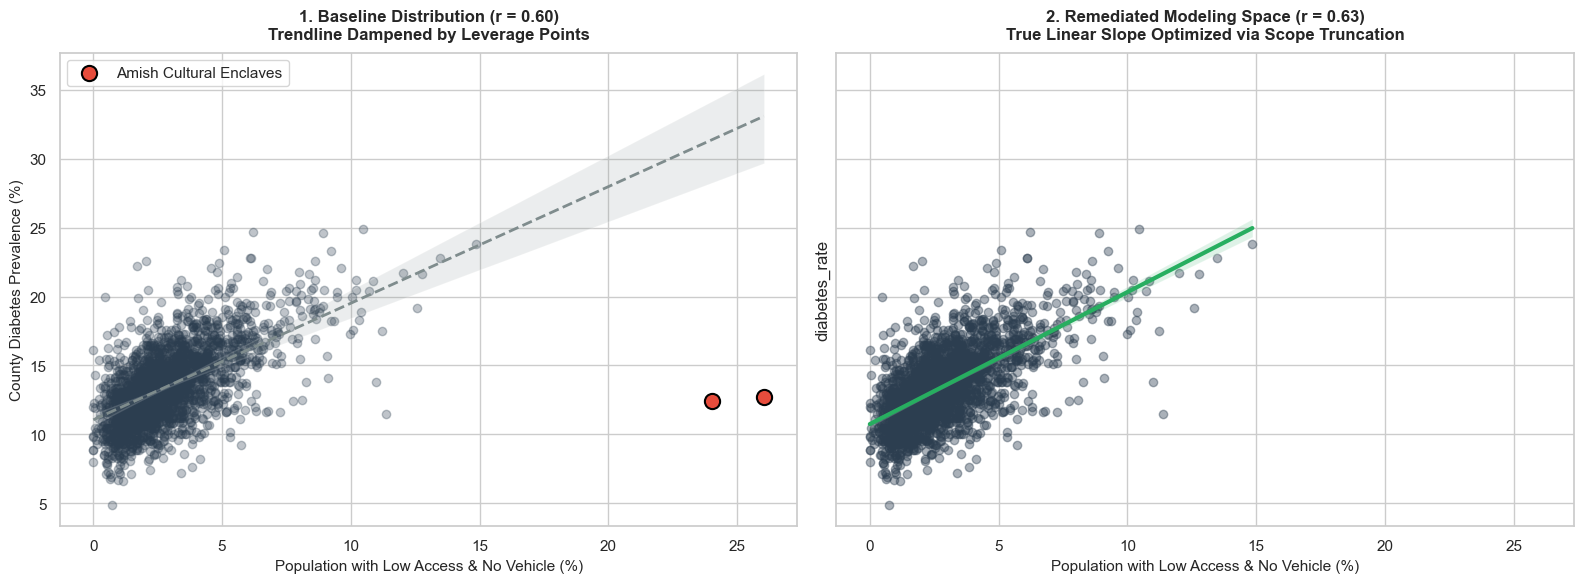

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Establish the final optimized modeling dataset by dropping the flagged indexes
df_model = df_clean.drop(outliers.index)

# 2. Re-run the core correlation matrix to quantify the mathematical shift
analysis_cols = ['pct_no_car_low_access', 'diabetes_rate', 'obesity_rate']
new_corr = df_model[analysis_cols].corr()

print("========================================================================")
print("REMEDIATED MODEL-READY CORRELATION MATRIX (OUTLIERS REMOVED)")
print("========================================================================")
print(new_corr.round(3))
print("========================================================================\n")

# 3. Initialize a synchronized dual-axis canvas utilizing shared axis constraints
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

# --- AXIS 0: BEFORE PROTOCOL ---
sns.regplot(
    data=df_clean, x='pct_no_car_low_access', y='diabetes_rate',
    scatter_kws={'alpha':0.3, 'color': '#2c3e50'},
    line_kws={'color': '#7f8c8d', 'linewidth': 2, 'linestyle':'--'},
    ax=axes[0]
)
# Overlay the targeted high-leverage points as high-visibility markers
axes[0].scatter(
    outliers['pct_no_car_low_access'], outliers['diabetes_rate'], 
    color='#e74c3c', s=120, edgecolor='black', linewidth=1.5, zorder=5, label='Amish Cultural Enclaves'
)
axes[0].set_title("1. Baseline Distribution (r = 0.60)\nTrendline Dampened by Leverage Points", fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel("Population with Low Access & No Vehicle (%)", fontsize=11)
axes[0].set_ylabel("County Diabetes Prevalence (%)", fontsize=11)
axes[0].legend(loc="upper left", frameon=True)

# --- AXIS 1: AFTER PROTOCOL ---
sns.regplot(
    data=df_model, x='pct_no_car_low_access', y='diabetes_rate',
    scatter_kws={'alpha':0.4, 'color': '#2c3e50'},
    line_kws={'color': '#27ae60', 'linewidth': 3}, # Bold emerald line representing the true optimized trend
    ax=axes[1]
)
axes[1].set_title("2. Remediated Modeling Space (r = 0.63)\nTrue Linear Slope Optimized via Scope Truncation", fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel("Population with Low Access & No Vehicle (%)", fontsize=11)

plt.tight_layout()
plt.show()

## 13. Linear Regression Modeling (OLS)

After completing exploratory analysis, data cleaning, and outlier review, a univariate Ordinary Least Squares (OLS) regression model was fitted to examine the relationship between infrastructure-related food access and diabetes prevalence.

The model is defined as:

$$y = \beta_0 + \beta_1 x + \epsilon$$

Where:

* $y$ represents diabetes prevalence (`diabetes_rate`)
* $\beta_0$ represents the intercept (baseline predicted diabetes rate when the independent variable is zero)
* $\beta_1$ represents the estimated change in diabetes prevalence associated with a one-unit increase in `pct_no_car_low_access`
* $\epsilon$ represents the error term

An intercept term was added using `sm.add_constant()`, and the model was estimated using least squares minimization.

The resulting output includes key statistics such as $R^2$, F-statistic, and p-values, which are used to evaluate the strength and significance of the relationship between variables.


In [15]:
# 1. Enforce absolute data purity by ensuring no lingering sparse records exist in our final target vectors
df_regression_ready = df_model.dropna(subset=['pct_no_car_low_access', 'diabetes_rate']).copy()

# 2. Segment our matrix into the explanatory feature vector (X) and target outcome vector (y)
X = df_regression_ready['pct_no_car_low_access']
y = df_regression_ready['diabetes_rate']

# 3. Append a structural column of ones to represent the intercept constant (beta_0) in the design matrix
X = sm.add_constant(X)

# 4. Fit the Ordinary Least Squares (OLS) regression model to the empirical distribution
model = sm.OLS(y, X).fit()

# 5. Generate and display the comprehensive, statistically rigorous summary report
print("========================================================================")
print("ORDINARY LEAST SQUARES (OLS) REGRESSION INTERACTION MATRIX")
print("========================================================================")
print(model.summary())
print("========================================================================")

ORDINARY LEAST SQUARES (OLS) REGRESSION INTERACTION MATRIX
                            OLS Regression Results                            
Dep. Variable:          diabetes_rate   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.403
Method:                 Least Squares   F-statistic:                     1637.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          6.43e-274
Time:                        09:31:40   Log-Likelihood:                -5232.3
No. Observations:                2425   AIC:                         1.047e+04
Df Residuals:                    2423   BIC:                         1.048e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

## 15. OLS Diagnostic Checks

To assess the validity of the Ordinary Least Squares (OLS) model, residuals were evaluated using three standard diagnostic plots:

1. **Residual Distribution (Histogram/KDE)**
   Assesses whether residuals are approximately normally distributed around zero.

2. **Q-Q Plot**
   Compares the distribution of residuals to a theoretical normal distribution to identify deviations such as skewness or heavy tails.

3. **Residuals vs. Fitted Values**
   Evaluates whether residual variance remains constant across predicted values (homoscedasticity) and helps identify potential non-linear patterns.

These diagnostic plots were used to assess how well the model assumptions align with the observed data and to identify potential limitations of the linear model.


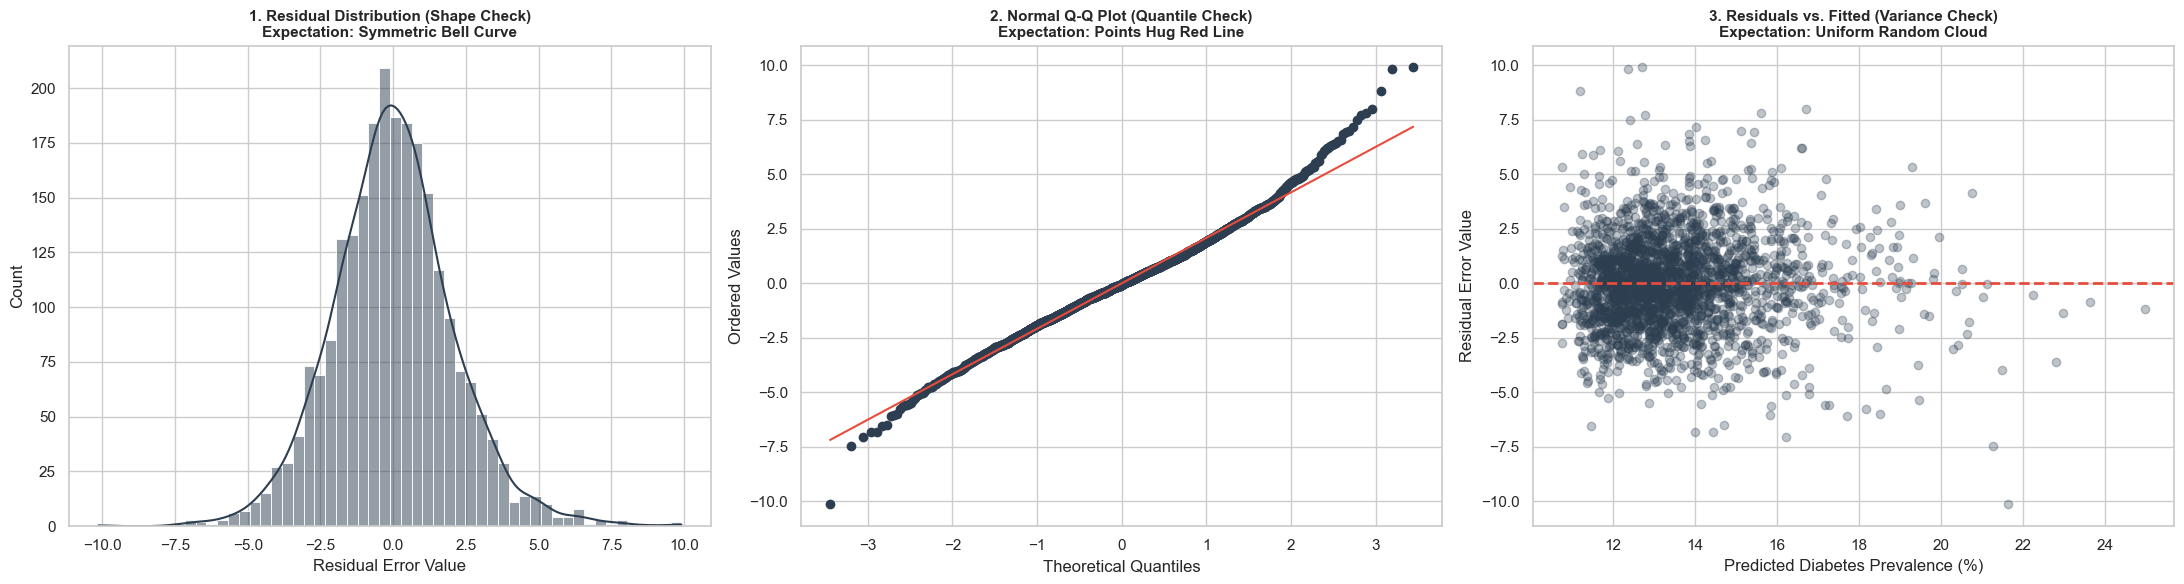

In [16]:
# 1. Extract raw residuals and fitted mathematical values from the OLS model instance
residuals = model.resid
fitted_values = model.fittedvalues

# 2. Initialize a high-resolution, 3-panel diagnostic sub-plotting environment
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
sns.set_theme(style="whitegrid")

# --- PANEL 1: UNIVARIATE ERROR DISTRIBUTION (NORMALITY TEST) ---
sns.histplot(residuals, kde=True, color='#2c3e50', ax=axes[0])
axes[0].set_title("1. Residual Distribution (Shape Check)\nExpectation: Symmetric Bell Curve", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Residual Error Value")

# --- PANEL 2: QUANTILE-QUANTILE PRECISION (EMPIRICAL VS. THEORETICAL) ---
stats.probplot(residuals, dist=stats.norm, plot=axes[1])
axes[1].get_lines()[0].set_color('#2c3e50') # Customize scatter density markers
axes[1].get_lines()[1].set_color('#e74c3c') # Customize theoretical normal reference vector
axes[1].set_title("2. Normal Q-Q Plot (Quantile Check)\nExpectation: Points Hug Red Line", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Theoretical Quantiles")
axes[1].set_ylabel("Ordered Values")

# --- PANEL 3: BIVARIATE ERROR VARIANCE (HOMOSCEDASTICITY AUDIT) ---
axes[2].scatter(fitted_values, residuals, alpha=0.3, color='#2c3e50')
axes[2].axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2) # Draw zero-error anchor line
axes[2].set_title("3. Residuals vs. Fitted (Variance Check)\nExpectation: Uniform Random Cloud", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Predicted Diabetes Prevalence (%)")
axes[2].set_ylabel("Residual Error Value")

plt.tight_layout()
plt.show()

## 16. Log Transformation and Model Comparison

To assess the impact of non-linearity in the independent variable, a natural logarithmic transformation was applied to `pct_no_car_low_access` using `log(x + c)`.

This transformation was used to reduce skewness and evaluate whether a log-transformed version of the variable improved model fit and residual behavior in the Ordinary Least Squares (OLS) regression.

A new model was then fitted using the transformed variable, and diagnostic plots were generated to compare residual patterns against the original linear specification.


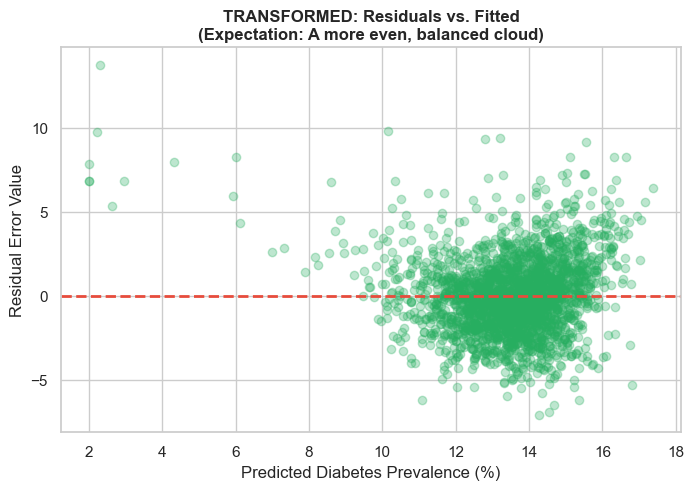

EXPERIMENTAL LOG-LINEAR OLS REGRESSION INTERACTION MATRIX
                            OLS Regression Results                            
Dep. Variable:          diabetes_rate   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     1075.
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          1.70e-195
Time:                        09:31:41   Log-Likelihood:                -5412.9
No. Observations:                2425   AIC:                         1.083e+04
Df Residuals:                    2423   BIC:                         1.084e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [17]:
# 1. Execute a non-linear natural logarithmic feature transformation to stabilize variance
# A minor constant floor (c = 0.01) is introduced to prevent mathematical undefined limits [ln(0)]
df_regression_ready['log_no_car'] = np.log(df_regression_ready['pct_no_car_low_access'] + 0.01)

# 2. Re-segment the design matrix and outcome vector using the transformed feature space
X_log = df_regression_ready['log_no_car']
y = df_regression_ready['diabetes_rate']
X_log = sm.add_constant(X_log)

# 3. Fit the log-linear Ordinary Least Squares (OLS) model structure
model_log = sm.OLS(y, X_log).fit()

# 4. Extract model residuals and fitted array values for post-transformation diagnostics
residuals_log = model_log.resid
fitted_values_log = model_log.fittedvalues

# 5. Project the transformed bivariate error distribution to audit homoscedasticity
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values_log, residuals_log, alpha=0.3, color='#27ae60') # Emerald configuration maps experimental model space
plt.axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2)         # Structural zero-error reference threshold
plt.title("TRANSFORMED: Residuals vs. Fitted\n(Expectation: A more even, balanced cloud)", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Diabetes Prevalence (%)")
plt.ylabel("Residual Error Value")
plt.show()

# 6. Generate and evaluate the updated parametric interaction summary matrix
print("========================================================================")
print("EXPERIMENTAL LOG-LINEAR OLS REGRESSION INTERACTION MATRIX")
print("========================================================================")
print(model_log.summary())
print("========================================================================")

### Evaluation of Log-Transformed Model

The log-transformed model was evaluated against the baseline OLS model to assess whether non-linear scaling improved model fit or residual behavior.

The results indicate that the log transformation did not improve model performance. Compared to the baseline model, the transformed version showed lower explanatory power and less stable residual patterns.

1. **Residual Pattern Changes:** The residual vs. fitted plot showed increased clustering and reduced dispersion compared to the baseline model.
2. **Effect of Transformation:** The log transformation likely compressed variation in the independent variable due to its bounded percentage range (0–100), which may reduce its suitability for logarithmic scaling.

### Model Selection Decision

Based on comparative performance, the original linear model was retained as the final specification:

* Coefficient: β₁ ≈ 0.96
* R² ≈ 0.403

This decision reflects a preference for the model that preserves higher explanatory power and clearer interpretability within this dataset.


## 17. Model Evaluation and Final Summary

Following model fitting and diagnostic evaluation, the relationship between infrastructure-related food access (`pct_no_car_low_access`) and diabetes prevalence (`diabetes_rate`) was assessed using a linear regression model.

### Model Performance Summary

1. **Baseline Linear Model**
   The Ordinary Least Squares (OLS) model showed a positive relationship between variables, with a statistically significant coefficient (p < 0.001) and an R² of 0.403. This indicates that approximately 40.3% of the variation in diabetes prevalence in this dataset is associated with differences in infrastructure-related food access.

2. **Residual Diagnostics**
   Residual plots indicated some deviation from normality and mild heteroscedasticity, particularly at lower values of the independent variable.

3. **Log-Transformed Model Comparison**
   A log-transformed version of the independent variable was tested to address skewness. This model resulted in a lower R² (0.307) and less stable residual patterns compared to the baseline linear model.

### Final Model Selection

Based on comparative performance, the original linear model was retained due to higher explanatory power and clearer interpretability within this dataset.

* Coefficient: β₁ ≈ 0.96
* R² ≈ 0.403

### Regional Pattern Exploration (Tableau Analysis)

The fitted model was also examined across regional subsets to explore variation in the relationship:

* **Southeast & Appalachian region:** Higher baseline diabetes prevalence and a steeper fitted relationship compared to the national dataset.
* **Southwest region:** Lower baseline levels and a flatter fitted relationship relative to the national trend.

These differences suggest that the relationship between infrastructure isolation and diabetes prevalence varies across regions and may be influenced by additional contextual factors not captured in this model.

### Conclusion

The linear model provides a useful baseline representation of the relationship between infrastructure-related food access and diabetes prevalence in this dataset. Regional analysis further highlights variation in this relationship across geographic areas.


In [18]:
# 1. Append model predictions and residual error arrays directly to the finalized design dataset
# This step ensures that our geospatial data points retain their individual spatial metadata for Tableau mapping
df_regression_ready['predicted_diabetes'] = model.fittedvalues
df_regression_ready['model_residuals'] = model.resid

# 2. Export the synchronized modeling matrix to a pristine CSV file for BI ingestion
# We retain the index mapping for subsequent data integrity validation
df_regression_ready.to_csv('food_access_diabetes_model_output.csv', index=False)

print("========================================================================")
print("ETL & MODELING PIPELINE EXECUTION COMPLETE")
print("========================================================================")
print("Status Code : 200 OK")
print("Output Asset: food_access_diabetes_model_output.csv")
print("Target Ingest: Tableau Business Intelligence Dashboarding Environment")
print("========================================================================")

ETL & MODELING PIPELINE EXECUTION COMPLETE
Status Code : 200 OK
Output Asset: food_access_diabetes_model_output.csv
Target Ingest: Tableau Business Intelligence Dashboarding Environment
